In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [4]:
Churn_data = pd.read_csv('Churn.csv')
Churn_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [5]:
# Observamos la inormación general del dataset
Churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


In [6]:
# Identificar variables no informativas, numéricas y categóricas
Churn_data.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure             float64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [7]:
# Identificar variables no informativas, numéricas y categóricas
var_no_informativa = ['RowNumber', 'CustomerId', 'Surname']
var_numerica = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'IsActiveMember', 'HasCrCard']
var_categorica = ['Geography', 'Gender']

In [8]:
# Eliminaremos las variables no informativas
Churn_data = Churn_data.drop(var_no_informativa, axis=1)

In [9]:
# Convertiremos las variables categóricas a numéricas
Churn_data = pd.get_dummies(Churn_data, drop_first=True, columns=var_categorica)


In [10]:
Churn_data

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2.0,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1.0,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8.0,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1.0,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2.0,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5.0,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10.0,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7.0,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3.0,75075.31,2,1,0,92888.52,1,True,False,True


In [11]:
# Reemplazaremos los valores nulos con la mediana de la columna Tenure
Churn_data['Tenure'] = Churn_data['Tenure'].fillna(value=Churn_data['Tenure'].median())

In [12]:
# Dividir datos de prueba y entrenamiento
from sklearn.model_selection import train_test_split

train_valid, test = train_test_split(Churn_data, test_size=0.2)
train, valid = train_test_split(train_valid, test_size=0.25)

features_train = train.drop(['Exited'], axis=1)
target_train = train['Exited']

features_valid = valid.drop(['Exited'], axis=1)
target_valid = valid['Exited']

features_test = test.drop(['Exited'], axis=1)
target_test = test['Exited']    

print('Set de entrenamiento:', features_train.shape)
print('Set de validación:', features_valid.shape)
print('Set de prueba:', features_test.shape)    

Set de entrenamiento: (6000, 11)
Set de validación: (2000, 11)
Set de prueba: (2000, 11)


In [13]:
# Estandarizar los datos
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_train[var_numerica] = scaler.fit_transform(features_train[var_numerica])
features_valid[var_numerica] = scaler.transform(features_valid[var_numerica])
features_test[var_numerica] = scaler.transform(features_test[var_numerica])

Revisaremos ahora si tenemos algún desbalance en los datos


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Exited
0    0.801333
1    0.198667
Name: proportion, dtype: float64


<Axes: xlabel='Exited'>

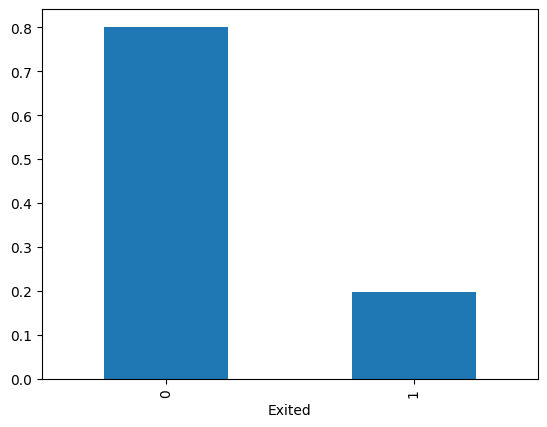

In [14]:
%pip install matplotlib
from matplotlib import pyplot as plt

# Revisamos el posible desbalance de datos
print(target_train.value_counts(normalize=True))
target_train.value_counts(normalize=True).plot(kind='bar')

Justo podemos observar que hay un desbalance en las clases

In [15]:
from sklearn.metrics import f1_score, roc_auc_score


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=12345)
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)
probability_valid = model.predict_proba(features_valid)[:, 1]

print('F1 Score:', f1_score(target_valid, predicted_valid))
print('ROC AUC Score:', roc_auc_score(target_valid, probability_valid))

F1 Score: 0.3351749539594843
ROC AUC Score: 0.7478630899596019


In [ ]:
from sklearn.tree import DecisionTreeClassifier

for depth in [1, 2, 4, 6, 8, None]:
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth)

    model.fit(features_train, target_train)
    predicted_valid = model.predict(features_valid)
    probability_valid = model.predict_proba(features_valid)[:, 1]

    print('Max Depth =', depth)
    print('   F1 Score =', f1_score(target_valid, predicted_valid))
    print('   ROC AUC Score =', roc_auc_score(target_valid, probability_valid))

Max Depth = 1
   F1 Score = 0.0
   ROC AUC Score = 0.6842238151542024
Max Depth = 2
   F1 Score = 0.49142857142857144
   ROC AUC Score = 0.7409843334318651
Max Depth = 4
   F1 Score = 0.49517684887459806
   ROC AUC Score = 0.8147023413636811
Max Depth = 6
   F1 Score = 0.5607476635514018
   ROC AUC Score = 0.8251390223174697
Max Depth = 8
   F1 Score = 0.5508100147275405
   ROC AUC Score = 0.8150079441324268
Max Depth = None
   F1 Score = 0.4994110718492344
   ROC AUC Score = 0.6878818110158637


In [20]:
from sklearn.ensemble import RandomForestClassifier 

for estim in range(10, 101, 10):
    model = RandomForestClassifier(random_state=12345, n_estimators=estim)

    model.fit(features_train, target_train)
    predicted_valid = model.predict(features_valid)
    probability_valid = model.predict_proba(features_valid)[:, 1]

    print('Number of Estimators =', estim)
    print('   F1 Score =', f1_score(target_valid, predicted_valid))
    print('   ROC AUC Score =', roc_auc_score(target_valid, probability_valid))

Number of Estimators = 10
   F1 Score = 0.5423728813559322
   ROC AUC Score = 0.8035759372844615
Number of Estimators = 20
   F1 Score = 0.5740458015267176
   ROC AUC Score = 0.8274037158833384
Number of Estimators = 30
   F1 Score = 0.5740181268882175
   ROC AUC Score = 0.836306224751207
Number of Estimators = 40
   F1 Score = 0.5762195121951219
   ROC AUC Score = 0.8387341117351463
Number of Estimators = 50
   F1 Score = 0.5753424657534246
   ROC AUC Score = 0.8380998127894373
Number of Estimators = 60
   F1 Score = 0.5714285714285714
   ROC AUC Score = 0.8409287552960882
Number of Estimators = 70
   F1 Score = 0.576271186440678
   ROC AUC Score = 0.8431849812789438
Number of Estimators = 80
   F1 Score = 0.5745007680491552
   ROC AUC Score = 0.8471116304562025
Number of Estimators = 90
   F1 Score = 0.5797546012269938
   ROC AUC Score = 0.8470708321016849
Number of Estimators = 100
   F1 Score = 0.5835866261398176
   ROC AUC Score = 0.8484779904424082


In [ ]:
# Modelo regresion logistica con balanceo de clases
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=12345, class_weight='balanced')
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)
probability_valid = model.predict_proba(features_valid)[:, 1]

print('F1 Score:', f1_score(target_valid, predicted_valid))
print('ROC AUC Score:', roc_auc_score(target_valid, probability_valid))

F1 Score: 0.47285464098073554
ROC AUC Score: 0.7563291334121588


In [ ]:
# Modelo Decision Tree con balanceo de clases
from sklearn.tree import DecisionTreeClassifier

for depth in [1, 2, 4, 6, 8, None]:
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth, class_weight='balanced')

    model.fit(features_train, target_train)
    predicted_valid = model.predict(features_valid)
    probability_valid = model.predict_proba(features_valid)[:, 1]

    print('Max Depth =', depth)
    print('   F1 Score =', f1_score(target_valid, predicted_valid))
    print('   ROC AUC Score =', roc_auc_score(target_valid, probability_valid))

Max Depth = 1
   F1 Score = 0.4813695871097684
   ROC AUC Score = 0.6842238151542024
Max Depth = 2
   F1 Score = 0.5203883495145631
   ROC AUC Score = 0.7409843334318651
Max Depth = 4
   F1 Score = 0.5410544511668107
   ROC AUC Score = 0.8168446398659966
Max Depth = 6
   F1 Score = 0.5719733079122974
   ROC AUC Score = 0.8298562358360428
Max Depth = 8
   F1 Score = 0.5746887966804979
   ROC AUC Score = 0.8062847940683812
Max Depth = None
   F1 Score = 0.46601941747572817
   ROC AUC Score = 0.664942358853089


In [23]:
# Modelo Random Forest con balanceo de clases
from sklearn.ensemble import RandomForestClassifier 

for estim in range(10, 101, 10):
    model = RandomForestClassifier(random_state=12345, n_estimators=estim, class_weight='balanced')

    model.fit(features_train, target_train)
    predicted_valid = model.predict(features_valid)
    probability_valid = model.predict_proba(features_valid)[:, 1]

    print('Number of Estimators =', estim)
    print('   F1 Score =', f1_score(target_valid, predicted_valid))
    print('   ROC AUC Score =', roc_auc_score(target_valid, probability_valid))

Number of Estimators = 10
   F1 Score = 0.5379746835443038
   ROC AUC Score = 0.8139718198837324
Number of Estimators = 20
   F1 Score = 0.5391849529780565
   ROC AUC Score = 0.8391805842940191
Number of Estimators = 30
   F1 Score = 0.5327102803738317
   ROC AUC Score = 0.8431511109468913
Number of Estimators = 40
   F1 Score = 0.5505443234836703
   ROC AUC Score = 0.846596647452951
Number of Estimators = 50
   F1 Score = 0.5590062111801242
   ROC AUC Score = 0.8491076707064734
Number of Estimators = 60
   F1 Score = 0.562111801242236
   ROC AUC Score = 0.8521198209183171
Number of Estimators = 70
   F1 Score = 0.5679012345679012
   ROC AUC Score = 0.8513077027293329
Number of Estimators = 80
   F1 Score = 0.5687789799072643
   ROC AUC Score = 0.8508458345649819
Number of Estimators = 90
   F1 Score = 0.5709876543209876
   ROC AUC Score = 0.8510136466646959
Number of Estimators = 100
   F1 Score = 0.5714285714285714
   ROC AUC Score = 0.8514716659276775


## Usaremos la técnica de upsampling para nuestros modelos

In [ ]:
# Modelo upsampling para crear nuevo dataset balanceado
from sklearn.utils import shuffle

def upsample(features, target, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
    target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

    features_upsampled, target_upsampled = shuffle(features_upsampled, target_upsampled, random_state=12345)

    return features_upsampled, target_upsampled
features_upsampled, target_upsampled = upsample(features_train, target_train, 3)

In [ ]:
# Modelo de regresion logistica usando la función de upsampling
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=12345)
model.fit(features_upsampled, target_upsampled)
predicted_valid = model.predict(features_valid)
probability_valid = model.predict_proba(features_valid)[:, 1]

print('F1 Score:', f1_score(target_valid, predicted_valid))
print('ROC AUC Score:', roc_auc_score(target_valid, probability_valid))

F1 Score: 0.48311156601842375
ROC AUC Score: 0.7549743201300622


In [26]:
# Modelo de decision tree con tecnica de upsampling
from sklearn.tree import DecisionTreeClassifier

for depth in [1, 2, 4, 6, 8, None]:
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth)

    model.fit(features_upsampled, target_upsampled)
    predicetd_valid = model.predict(features_valid)
    probability_valid = model.predict_proba(features_valid)[:, 1]

    print('Max Depth =', depth)
    print('   F1 Score =', f1_score(target_valid, predicetd_valid))
    print('   ROC AUC Score =', roc_auc_score(target_valid, probability_valid))

Max Depth = 1
   F1 Score = 0.4813695871097684
   ROC AUC Score = 0.6842238151542024
Max Depth = 2
   F1 Score = 0.49142857142857144
   ROC AUC Score = 0.7409843334318651
Max Depth = 4
   F1 Score = 0.5511961722488038
   ROC AUC Score = 0.812850250024633
Max Depth = 6
   F1 Score = 0.5719882468168462
   ROC AUC Score = 0.8322895112818998
Max Depth = 8
   F1 Score = 0.5837957824639289
   ROC AUC Score = 0.7925927123361908
Max Depth = None
   F1 Score = 0.4900497512437811
   ROC AUC Score = 0.678921568627451


In [27]:
# Random Forest con tecnica de upsampling
from sklearn.ensemble import RandomForestClassifier 

for estim in range(10, 101, 10):
    model = RandomForestClassifier(random_state=12345, n_estimators=estim)

    model.fit(features_upsampled, target_upsampled)
    predicted_valid = model.predict(features_valid)
    probability_valid = model.predict_proba(features_valid)[:, 1]

    print('Number of Estimators =', estim)
    print('   F1 Score =', f1_score(target_valid, predicted_valid))
    print('   ROC AUC Score =', roc_auc_score(target_valid, probability_valid))

Number of Estimators = 10
   F1 Score = 0.5777166437414031
   ROC AUC Score = 0.8235363397871711
Number of Estimators = 20
   F1 Score = 0.5791610284167794
   ROC AUC Score = 0.8315913205734555
Number of Estimators = 30
   F1 Score = 0.5876010781671159
   ROC AUC Score = 0.8360183269287613
Number of Estimators = 40
   F1 Score = 0.5866666666666667
   ROC AUC Score = 0.8407678712188393
Number of Estimators = 50
   F1 Score = 0.5918918918918918
   ROC AUC Score = 0.8416816004039807
Number of Estimators = 60
   F1 Score = 0.584573748308525
   ROC AUC Score = 0.8435698714159031
Number of Estimators = 70
   F1 Score = 0.5896739130434783
   ROC AUC Score = 0.8434590230564587
Number of Estimators = 80
   F1 Score = 0.5888738127544098
   ROC AUC Score = 0.8455474369396
Number of Estimators = 90
   F1 Score = 0.5807327001356852
   ROC AUC Score = 0.8463018216080402
Number of Estimators = 100
   F1 Score = 0.5814266487213997
   ROC AUC Score = 0.8481092656912012


Hasta ahorita el modelo de Random Fores presenta el mejor F1 score de 0.591 con 50 estimadores

## Usaremos la técnica de downsampling para nuestros modelos

In [30]:
# Tecnica de downsampling
def downsample(features, target, fraction):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_downsampled = pd.concat([features_zeros.sample(frac=fraction, random_state=12345)] + [features_ones])
    target_downsampled = pd.concat([target_zeros.sample(frac=fraction, random_state=12345)] + [target_ones])

    features_downsampled, target_downsampled = shuffle(features_downsampled, target_downsampled, random_state=12345)

    return features_downsampled, target_downsampled
features_downsampled, target_downsampled = downsample(features_train, target_train, 0.3)

In [31]:
# Modelo regresion logistica con técnica de downsampling

model = LogisticRegression(random_state=12345)
model.fit(features_downsampled, target_downsampled)
predicted_valid = model.predict(features_valid)
probability_valid = model.predict_proba(features_valid)[:, 1]

print('F1 Score:', f1_score(target_valid, predicted_valid))
print('ROC AUC Score:', roc_auc_score(target_valid, probability_valid))

F1 Score: 0.46956521739130436
ROC AUC Score: 0.750254027490393


In [32]:
# Modelo Decision tree con técnica de downsampling

for depth in [1, 2, 4, 6, 8, None]:
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth)

    model.fit(features_downsampled, target_downsampled)
    predicted_valid = model.predict(features_valid)
    probability_valid = model.predict_proba(features_valid)[:, 1]

    print('Max Depth =', depth)
    print('   F1 Score =', f1_score(target_valid, predicted_valid))
    print('   ROC AUC Score =', roc_auc_score(target_valid, probability_valid))

Max Depth = 1
   F1 Score = 0.4813695871097684
   ROC AUC Score = 0.6842238151542024
Max Depth = 2
   F1 Score = 0.5203883495145631
   ROC AUC Score = 0.7409843334318651
Max Depth = 4
   F1 Score = 0.5416666666666666
   ROC AUC Score = 0.811354566952409
Max Depth = 6
   F1 Score = 0.5637065637065637
   ROC AUC Score = 0.8224894386146417
Max Depth = 8
   F1 Score = 0.5687693898655636
   ROC AUC Score = 0.8037391307025321
Max Depth = None
   F1 Score = 0.47007805724197743
   ROC AUC Score = 0.6832384964035865


In [33]:
# Modelo Random forest con técnica de downsampling

for estim in range(10, 101, 10):
    model = RandomForestClassifier(random_state=12345, n_estimators=estim)

    model.fit(features_downsampled, target_downsampled)
    predicted_valid = model.predict(features_valid)
    probability_valid = model.predict_proba(features_valid)[:, 1]

    print('Number of Estimators =', estim)
    print('   F1 Score =', f1_score(target_valid, predicted_valid))
    print('   ROC AUC Score =', roc_auc_score(target_valid, probability_valid))

Number of Estimators = 10
   F1 Score = 0.5624321389793703
   ROC AUC Score = 0.8191154916740565
Number of Estimators = 20
   F1 Score = 0.5795574288724974
   ROC AUC Score = 0.8356734653660458
Number of Estimators = 30
   F1 Score = 0.5869120654396728
   ROC AUC Score = 0.843986322544093
Number of Estimators = 40
   F1 Score = 0.5857142857142857
   ROC AUC Score = 0.8467744666962262
Number of Estimators = 50
   F1 Score = 0.5885947046843177
   ROC AUC Score = 0.8467636897723914
Number of Estimators = 60
   F1 Score = 0.5925925925925926
   ROC AUC Score = 0.8474387870726181
Number of Estimators = 70
   F1 Score = 0.5950920245398773
   ROC AUC Score = 0.8477051310473939
Number of Estimators = 80
   F1 Score = 0.6026557711950971
   ROC AUC Score = 0.8480838629421618
Number of Estimators = 90
   F1 Score = 0.5915201654601862
   ROC AUC Score = 0.8474780458665879
Number of Estimators = 100
   F1 Score = 0.5846153846153846
   ROC AUC Score = 0.8473949095970047


Nos quedaremos con nuestro mejor modelo que hasta ahora es RandomForest con 80 estimators, F1 Score de 0.602 y ROC AUC Score de 0.848

## Evaluación de nuestro modelo escogido

In [35]:
features_full_train = pd.concat([features_train, features_valid])
target_full_train = pd.concat([target_train, target_valid])

features_downsampled, target_downsampled = downsample(features_full_train, target_full_train, 0.3)

model = RandomForestClassifier(random_state=12345, n_estimators=80)
model.fit(features_downsampled, target_downsampled)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",80
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [36]:
predicted_test = model.predict(features_test)
probability_test = model.predict_proba(features_test)[:, 1]

print('F1 Score:', f1_score(target_test, predicted_test))
print('ROC AUC Score:', roc_auc_score(target_test, probability_test))

F1 Score: 0.6199616122840691
ROC AUC Score: 0.8590020072295401
